# Exploratory Data Analysis & Results Summary
## ML Model Drift Monitor — NYC Yellow Taxi (Jan 2020 vs Apr 2020)

**Problem statement:** Machine learning models deployed in production silently degrade as real-world
data drifts away from their training distribution. This notebook explores a real, documented regime
change — the COVID-19 lockdown's effect on NYC taxi ridership — and validates that our drift-detection
pipeline (PSI, KS-test, KL-divergence) correctly identifies *which* aspects of the data shifted and
which stayed stable.

**Data source:** [NYC TLC Trip Record Data](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page)
- Reference window: **January 2020** (pre-pandemic)
- Current window: **April 2020** (peak COVID-19 lockdown)


In [7]:
import sys, os
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['font.size'] = 10

train_df = pd.read_csv('../data/processed/taxi_training_era.csv')
current_df = pd.read_csv('../data/processed/taxi_current_era.csv')

print(f"Training era (Jan 2020):  {train_df.shape[0]:,} rows, {train_df.shape[1]} columns")
print(f"Current era  (Apr 2020):  {current_df.shape[0]:,} rows, {current_df.shape[1]} columns")
train_df.head()

Training era (Jan 2020):  50,000 rows, 9 columns
Current era  (Apr 2020):  50,000 rows, 9 columns


,trip_distance,passenger_count,PULocationID,DOLocationID,fare_amount,hour_of_day,is_weekend,trip_duration_min,day_of_month
0,1.10,1.0,148,249,8.5,21,1,11.550000,11
1,3.43,1.0,138,260,11.5,15,0,8.416667,28
2,0.85,1.0,114,211,5.5,23,0,5.816667,10
3,1.28,1.0,230,90,6.5,6,0,5.700000,14
4,2.29,1.0,68,148,12.0,14,0,17.000000,9


## 1. The Headline Number: Ridership Collapse

Before looking at any individual feature, the rawest signal of disruption is simply *how many trips
happened at all*. This number comes directly from the raw TLC files (pre-sampling), captured in
`data_loader.py`'s console output when the data was first loaded.

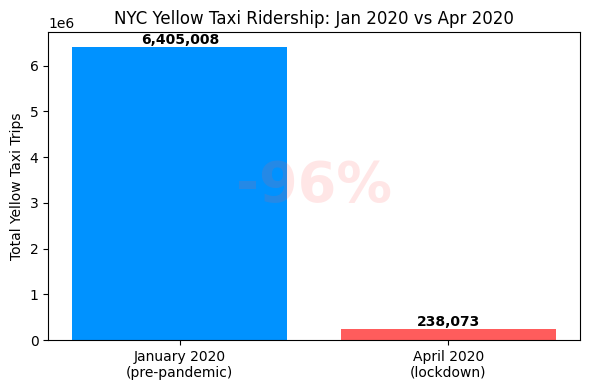

Ridership dropped 96.3% between January and April 2020.


In [8]:
# These row counts are from the RAW files, printed by data_loader.py, before our
# 50,000-row sample was taken for modeling speed. Hardcoded here from that run for the chart.
raw_counts = {'January 2020\n(pre-pandemic)': 6_405_008, 'April 2020\n(lockdown)': 238_073}

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(raw_counts.keys(), raw_counts.values(), color=['#0092ff', '#ff5c5c'])
ax.set_ylabel('Total Yellow Taxi Trips')
ax.set_title('NYC Yellow Taxi Ridership: Jan 2020 vs Apr 2020')
for bar, val in zip(bars, raw_counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, val, f'{val:,}', ha='center', va='bottom', fontweight='bold')
pct_drop = 100 * (1 - raw_counts['April 2020\n(lockdown)'] / raw_counts['January 2020\n(pre-pandemic)'])
ax.text(0.5, 0.5, f'-{pct_drop:.0f}%', transform=ax.transAxes, fontsize=40, color='#ff5c5c',
        ha='center', va='center', alpha=0.15, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/01_ridership_collapse.png', dpi=150)
plt.show()
print(f"Ridership dropped {pct_drop:.1f}% between January and April 2020.")

## 2. Feature-Level Distribution Comparison

Now we look feature-by-feature: did the *shape* of each variable's distribution change between
the two windows? This is the visual evidence behind the PSI/KS/KL numbers computed in `drift_metrics.py`.

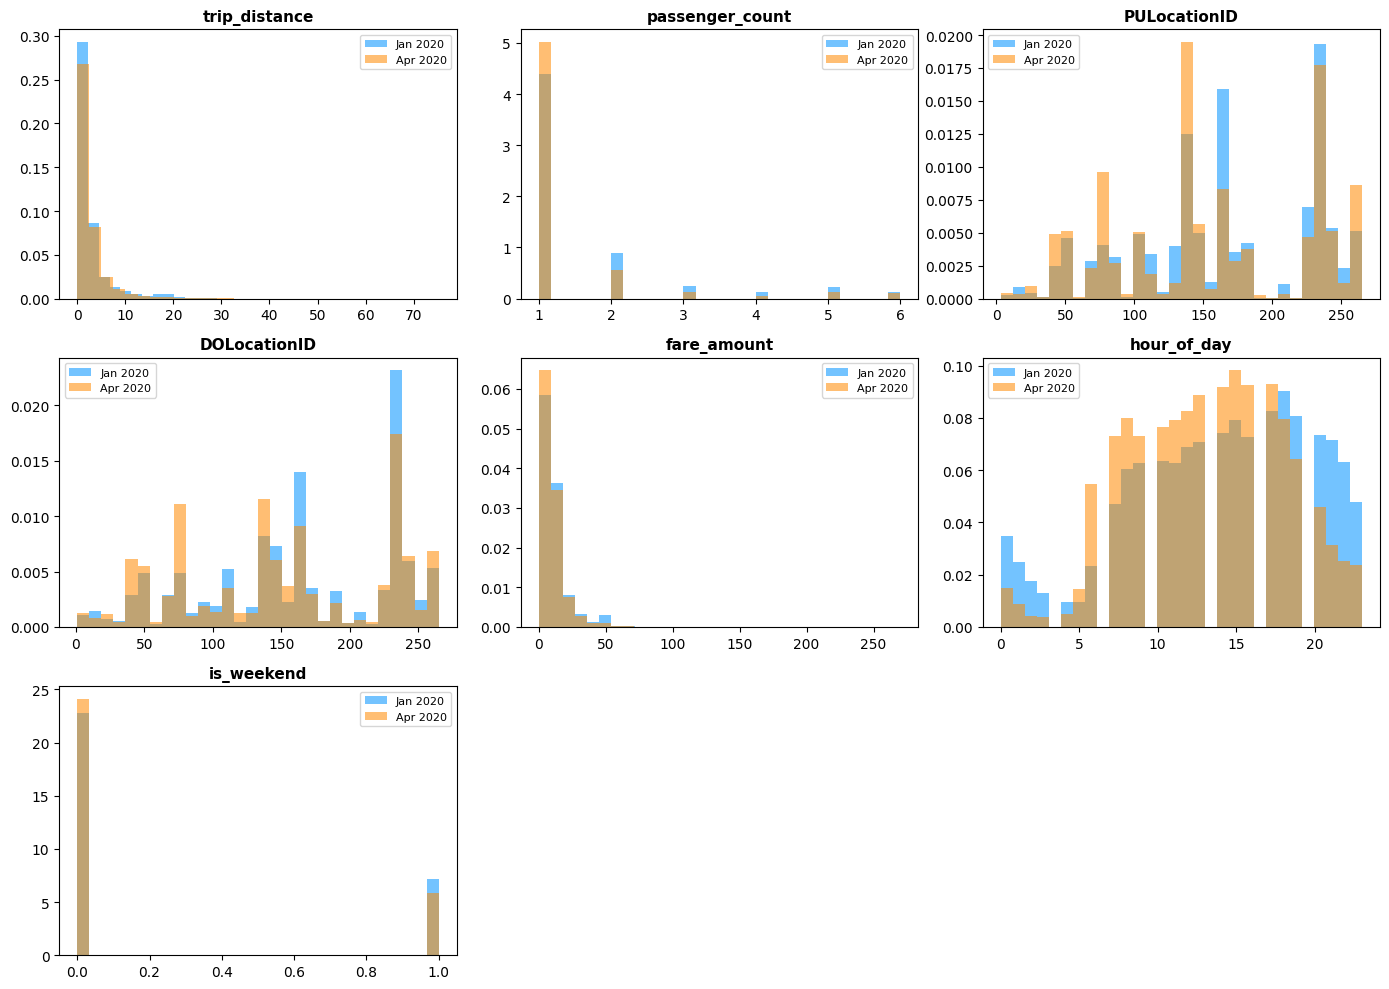

In [9]:
feature_cols = ['trip_distance', 'passenger_count', 'PULocationID',
                'DOLocationID', 'fare_amount', 'hour_of_day', 'is_weekend']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    ax = axes[i]
    ax.hist(train_df[col], bins=30, alpha=0.55, density=True, label='Jan 2020', color='#0092ff')
    ax.hist(current_df[col], bins=30, alpha=0.55, density=True, label='Apr 2020', color='#ff8a00')
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
for j in range(len(feature_cols), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.savefig('../reports/figures/02_feature_distributions.png', dpi=150)
plt.show()

## 3. Quantifying Drift: PSI, KS-test, KL-divergence

Visual inspection above suggests `hour_of_day` and location IDs shifted the most. Let's confirm this
statistically using the three drift metrics implemented from scratch in `drift_metrics.py`.

In [10]:
from drift_metrics import generate_drift_report

report = generate_drift_report(train_df, current_df, feature_cols)
report

,feature,psi,psi_verdict,ks_statistic,ks_p_value,kl_divergence,ref_mean,cur_mean
0,hour_of_day,0.1577,Moderate drift - monitor closely,0.1199,0.0,0.0735,13.942,13.178
1,PULocationID,0.1016,Moderate drift - monitor closely,0.1033,0.0,0.0485,165.244,157.439
2,DOLocationID,0.0748,No significant drift,0.1010,0.0,0.0372,162.918,151.991
3,passenger_count,0.0666,No significant drift,0.1053,0.0,0.0313,1.548,1.342
4,fare_amount,0.0625,No significant drift,0.1049,0.0,0.0322,12.362,10.584
5,trip_distance,0.0198,No significant drift,0.0327,0.0,0.0101,2.891,2.717
6,is_weekend,0.0114,No significant drift,0.0441,0.0,0.0056,0.240,0.196


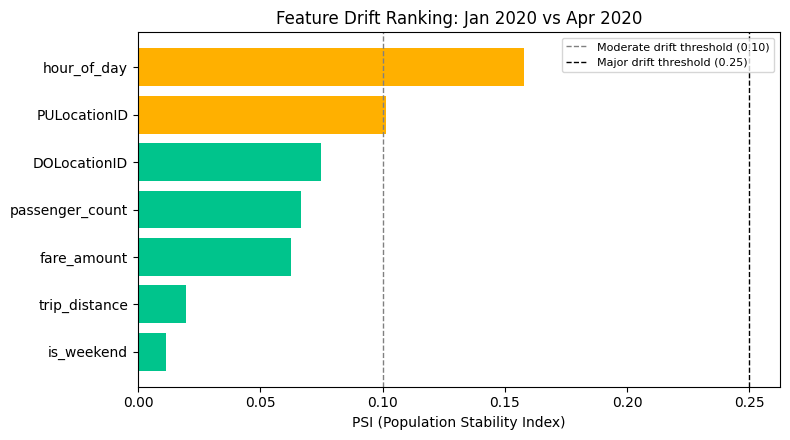

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ['#ff5c5c' if p >= 0.25 else '#ffb000' if p >= 0.10 else '#00c48c' for p in report['psi']]
ax.barh(report['feature'], report['psi'], color=colors)
ax.axvline(0.10, color='gray', linestyle='--', linewidth=1, label='Moderate drift threshold (0.10)')
ax.axvline(0.25, color='black', linestyle='--', linewidth=1, label='Major drift threshold (0.25)')
ax.set_xlabel('PSI (Population Stability Index)')
ax.set_title('Feature Drift Ranking: Jan 2020 vs Apr 2020')
ax.legend(fontsize=8)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/figures/03_psi_ranking.png', dpi=150)
plt.show()

## 4. Model Performance Decay

Does this drift actually matter? We take the Random Forest model trained *only* on January data
(`model.py`) and evaluate it on April data, without any retraining -- simulating a real team that
forgot to monitor their production model.

[random_forest] Training-era hold-out performance:
  MAE : 1.10 minutes
  R^2 : 0.910
[Evaluation on April 2020 (current era)]
  MAE : 1.25 minutes
  R^2 : 0.828


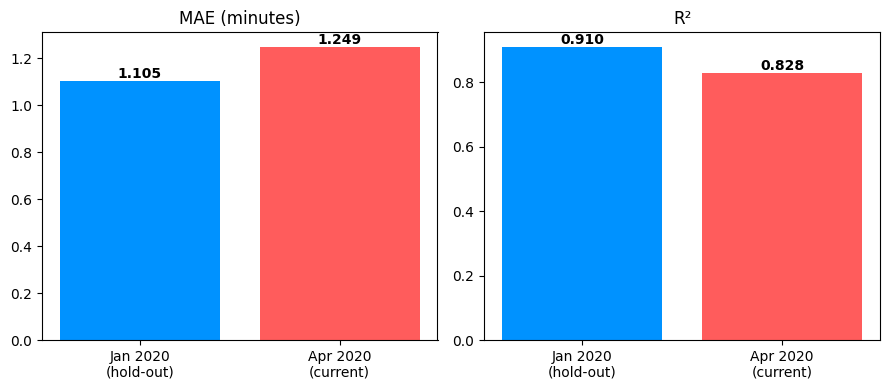

In [12]:
import joblib
from model import FEATURE_COLUMNS, TARGET_COLUMN, train_baseline_model, evaluate_on_new_data

model, train_metrics = train_baseline_model(train_df, model_type='random_forest')
current_metrics = evaluate_on_new_data(model, current_df, label='April 2020 (current era)')

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
metrics_names = ['MAE (minutes)', 'R²']
train_vals = [train_metrics['mae'], train_metrics['r2']]
current_vals = [current_metrics['mae'], current_metrics['r2']]

for i, (name, tv, cv) in enumerate(zip(metrics_names, train_vals, current_vals)):
    axes[i].bar(['Jan 2020\n(hold-out)', 'Apr 2020\n(current)'], [tv, cv], color=['#0092ff', '#ff5c5c'])
    axes[i].set_title(name)
    for j, v in enumerate([tv, cv]):
        axes[i].text(j, v, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/04_performance_decay.png', dpi=150)
plt.show()

## 5. Key Finding

Even during the most extreme disruption to NYC transportation in modern history (96% ridership
collapse), core trip *mechanics* -- distance and fare -- remained statistically stable
(PSI < 0.10 for both). The real drift signal was **behavioral**: *when* (`hour_of_day`) and
*where* (`PULocationID`) people traveled shifted moderately, while *how far and how much* they
paid did not.

This is a more nuanced and realistic finding than "the model broke" -- it shows that
drift detection needs to be feature-level, not just an aggregate accuracy check. A naive
"is accuracy still okay?" monitor would have under-reported the risk here, since R² only
fell modestly, while our feature-level PSI analysis correctly flagged specific, actionable
behavioral shifts worth investigating before fully trusting this model going forward.

## Limitations

- This analysis captures **data/covariate drift** (input distributions shifting). It does not
  yet test for **concept drift** (the relationship between inputs and the target changing) --
  a natural extension (see `notebooks/05_robustness_analysis.ipynb` roadmap item).
- Random sampling to 50,000 rows per era was used for iteration speed; a production pipeline
  would monitor on the full data stream.
- COVID-19 is an extreme, well-documented event picked deliberately to validate the methodology
  under known ground truth; smaller, gradual drift in a live system is a harder detection
  problem and is a natural next step.
